# **Jeep Class Comprehensive Diagnostics**

### **Node** (in node.py)

In [ ]:
from typing import Any, Callable, Optional
from rich import print
import math

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result

def assert_true(condition: bool, message: str) -> bool:
    if not condition:
        raise AssertionError(message)
    return True


def is_on_route(pos, route, tolerance=1e-6) -> bool:
    x, y = pos

    for edge in route.path:
        x1, y1 = edge.start.lat, edge.start.lon
        x2, y2 = edge.end.lat, edge.end.lon

        if not (min(x1, x2) - tolerance <= x <= max(x1, x2) + tolerance and
                min(y1, y2) - tolerance <= y <= max(y1, y2) + tolerance):
            continue

        dx = x2 - x1
        dy = y2 - y1

        if dx == 0 and dy == 0:
            continue

        cross = abs((x - x1) * dy - (y - y1) * dx)

        if cross < tolerance:
            return True

    return False

In [ ]:
class FakeNode:
    def __init__(self, lat: float, lon: float, layer: Optional[int] = None) -> None:
        self.lat = lat
        self.lon = lon
        self.layer = layer
        self.id = f"N_mock_{hash((lat, lon, layer))}"

    def __repr__(self) -> str:
        return f"Node({self.lat}, {self.lon})"

    def __eq__(self, other):
        if not isinstance(other, FakeNode):
            return False
        return self.lat == other.lat and self.lon == other.lon and self.layer == other.layer


class FakeEdge:
    def __init__(self, start: FakeNode, end: FakeNode, weight: float = 1.0) -> None:
        self.start = start
        self.end = end
        self.weight = weight
        self.id = f"E_mock_{hash((start.id, end.id))}"

    def getLength(self) -> float:
        dx = self.end.lon - self.start.lon
        dy = self.end.lat - self.start.lat
        return math.sqrt(dx * dx + dy * dy)

    def __repr__(self) -> str:
        return f"Edge({self.start.id} -> {self.end.id}, len={self.getLength():.3f})"


class FakeRoute:
    def __init__(self, path: list[FakeEdge], route_id: str = "R_test", color: str = "#FF0000") -> None:
        self.path = path
        self.id = route_id
        self.designated_color = color

    def __repr__(self) -> str:
        return f"Route({self.id}, {len(self.path)} edges, color={self.designated_color})"

# Triangle loop: (0,0) -> (0,1) -> (1,1) -> (0,0)
triangle_n1 = FakeNode(0.0, 0.0)
triangle_n2 = FakeNode(0.0, 1.0)
triangle_n3 = FakeNode(1.0, 1.0)
triangle_e1 = FakeEdge(triangle_n1, triangle_n2, weight=1.0)
triangle_e2 = FakeEdge(triangle_n2, triangle_n3, weight=math.sqrt(2))
triangle_e3 = FakeEdge(triangle_n3, triangle_n1, weight=math.sqrt(2))
triangle_route = FakeRoute([triangle_e1, triangle_e2, triangle_e3], "R_triangle", "#FF5733")

# Linear path (open, then close): (0,0) -> (1,0) -> (2,0) -> (2,0) [self-loop back]
linear_n1 = FakeNode(0.0, 0.0)
linear_n2 = FakeNode(0.0, 1.0)
linear_n3 = FakeNode(0.0, 2.0)
linear_e1 = FakeEdge(linear_n1, linear_n2, weight=1.0)
linear_e2 = FakeEdge(linear_n2, linear_n3, weight=1.0)
linear_e3 = FakeEdge(linear_n3, linear_n1, weight=2.0)  # Return edge
linear_route = FakeRoute([linear_e1, linear_e2, linear_e3], "R_linear", "#00FF00")

# Complex polygon (square)
square_n1 = FakeNode(0.0, 0.0)
square_n2 = FakeNode(0.0, 1.0)
square_n3 = FakeNode(1.0, 1.0)
square_n4 = FakeNode(1.0, 0.0)
square_e1 = FakeEdge(square_n1, square_n2, weight=1.0)
square_e2 = FakeEdge(square_n2, square_n3, weight=1.0)
square_e3 = FakeEdge(square_n3, square_n4, weight=1.0)
square_e4 = FakeEdge(square_n4, square_n1, weight=1.0)
square_route = FakeRoute([square_e1, square_e2, square_e3, square_e4], "R_square", "#0000FF")


In [ ]:
from utils.jeep import Jeep

def init_valid_jeep() -> Jeep:
    return Jeep(route=triangle_route, curr_pos=(0.0, 0.0), speed=10.0)

jeep = validate_call(
    "Jeep(triangle_route, (0.1, 0.1), speed=10.0)",
    True,
    init_valid_jeep
)

if jeep:
    print(f"\n{jeep}")
    print(f"  Jeep ID: {jeep.id}")
    print(f"  Route: {jeep.route.id}")
    print(f"  Route Color: {jeep.route.designated_color}")
    print(f"  Jeep Color: {jeep.designated_color}")
    print(f"  Speed: {jeep.speed} km/h")
    print(f"  Position: {jeep.curr_pos}")
    print(f"  Heading: {jeep.heading:.2f}°")
    print(f"  Passengers: {jeep.curr_passenger_count}/{jeep.passenger_max}")

def verify_init_contract() -> bool:
    j1 = Jeep(route=triangle_route, curr_pos=(0.0, 0.0), speed=10.0)
    j2 = Jeep(route=triangle_route, curr_pos=(0.0, 0.0), speed=10.0)

    assert_true(
        j1.id != j2.id, 
        "Jeep IDs must be unique"
    )
    
    assert_true(
        j1.designated_color == triangle_route.designated_color,
        "Jeep color must match route"
    )

    assert_true(j1.speed == 10.0, "Speed must be preserved in km/h")
    assert_true(j1.curr_passenger_count == 0, "Initial passengers must be 0")
    assert_true(j1.passenger_max == 16, "Max passengers must be 16")

    return True

def verify_position_on_route() -> bool:
    j = Jeep(
        route=triangle_route, 
        curr_pos=(0.1, 0.1), 
        speed=10.0
    )

    for _ in range(50):
        j.update()

        assert_true(is_on_route(j.curr_pos, triangle_route), "Jeep must stay on route")

    return True
    
validate_call("Jeep initialization contract", True, verify_init_contract)

[VALIDATED] Jeep(triangle_route, (0.1, 0.1), speed=10.0): Executed successfully.

Jeep(Jd53b6ac5c8dc42cf8496aaac642defde): route=R_triangle, pos=(0.0, 0.0), heading=-90.00°, passengers=0/16, 
speed=10.0 m/s, color=#FF5733

Jeep ID: Jd53b6ac5c8dc42cf8496aaac642defde

Route: R_triangle

Route Color: #FF5733

...

Position: (0.0, 0.0)

Heading: -90.00°

Passengers: 0/16

[VALIDATED] Jeep initialization contract: Executed successfully.

True

GIF Animation Test

Generated 40 frames.

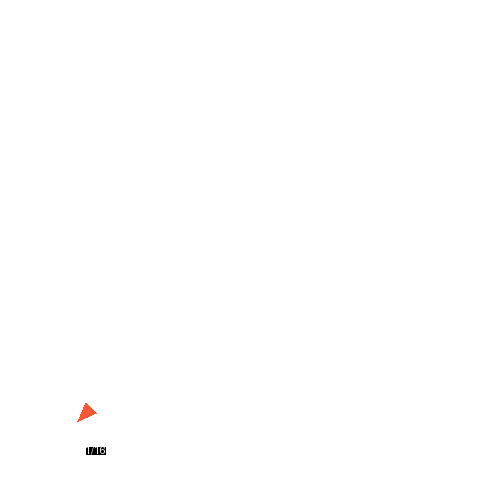

[VALIDATED] Jeep visualization GIF test: Executed successfully.

True

In [ ]:
from PIL import Image
from IPython.display import display, Image as IPyImage
import io

def test_jeep_visualization() -> bool:

    context = (
        (0.0, 1.0),
        (1.0, 0.0)
    )

    jeep_gif = Jeep(
        route=triangle_route, 
        curr_pos=(0.0, 0.0), 
        speed=10.0
    )

    frames = []

    for step in range(40):

        if step % 5 == 0:
            jeep_gif.modify_passenger(1)

        jeep_gif.update()

        assert_true(is_on_route(jeep_gif.curr_pos, triangle_route), "Jeep must remain on route")
        frame = jeep_gif.draw(
            context=context, 
            image=Image.new("RGB", (500, 500), "white"), 
            radius=15
        )

        frames.append(frame)
        jeep_gif.update()

    print(f"Generated {len(frames)} frames.")

    gif_stream = io.BytesIO()
    frames[0].save(
        gif_stream, 
        format="GIF", 
        save_all=True, 
        append_images=frames[1:], 
        duration=120, loop=0
    )
    
    gif_stream.seek(0)
    display(IPyImage(data=gif_stream.getvalue(), format="gif"))

    return True


validate_call("Jeep visualization GIF test", True, test_jeep_visualization)